# 선형 회귀

## K-최근접 이웃 알고리즘의 한계

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt


In [2]:
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [3]:
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

# 2차원으로 변환
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [4]:
# knn 모델 생성
knr = KNeighborsRegressor(n_neighbors=3)
# 훈련
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [5]:
# 길이가 50cm인 농어는 무게가 어느정도일지 예측해보기
print(knr.predict([[50]]))

[1033.33333333]


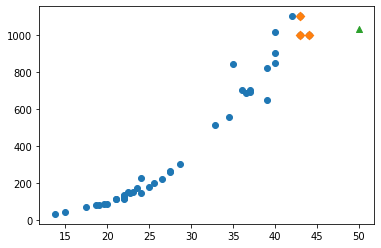

In [6]:

# 50cm 농어와 가장 가까운 이웃 3개의 인덱스 구하기
_, indexes = knr.kneighbors([[50]])

# 훈련세트의 산점도
plt.scatter(train_input, train_target)

# 50cm 농어와 가까운 이웃들 산점도에 표시 marker 옵션으로 다이아몬드 모양
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 50cm 농어의 위치 산점에도 표시, marker옵션으로 세모모양 
plt.scatter(50, 1033, marker='^')
plt.show()

---

## KNN 한계
시각화하여 표를 그려서 확인해보면, 길이가 커질수록 무게 또한 증가하는 경향이 보인다. 그러나 knn 이웃 알고리즘은 예측하고자하는 샘플 데이터에서 가장 가까운 이웃들의 값을 평균을 내서 구하기 때문에 문제가 발생한다.

현재 알고리즘에서 농어가 100cm여도, 150cm여도 예측되는 값은 1033.3333이 될 것

---

In [7]:
print(knr.predict([[100]]))
print(knr.predict([[200]]))

[1033.33333333]
[1033.33333333]


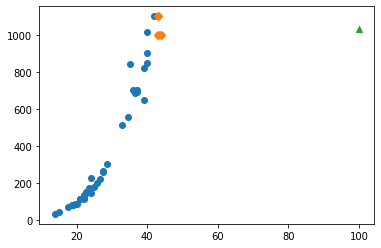

In [8]:
_, indexes = knr.kneighbors([[100]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(100, 1033, marker='^')
plt.show()

---

그래프에서 확인할 수 있듯이, 아무리 길이가 늘어나도 가장 가까운 이웃이 변하지 않는다.

## 선형 회귀
선형? -> 직선!<br>
직선 그래프를 나타내는 함수 $y = ax + b$<br>
위 함수에서 x의 값에 따라 y가 변하게 된다. 즉 y가 종속변수, x가 독립변수이다<br>
또는 y는 타겟값, x는 인풋값

선형회귀는 이러한 직선을 구하는 알고리즘이다

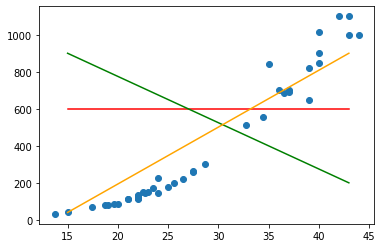

In [9]:

plt.scatter(train_input, train_target)
plt.plot([15,43],[600,600], color = "red")
plt.plot([15,43],[900,200], color = "green")
plt.plot([15,43],[40,900], color = "orange")
plt.show()

위의 표를 보면 농어 데이터를 표현하는것에 가장 근접한 직선은 주황색 직선이며, 이런 직선을 자동으로 구해주는 것이 선형회귀 알고리즘이다. 즉 $y = ax + b$
라는 방정식에서 기울기 a의 값과 y절편 b의 값을 구해준다. 머신러닝에서는 기울기를 계수(coefficient) 또는 가중치(weight)라고 한다.

### LinearRegression
- `fit()`
- `score()`
- `predict()`

In [11]:
# 사이킷런에서 선형회귀 임포트
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
# 선형 회귀 모델 훈련
lr.fit(train_input, train_target)
# 50cm 농어에 대한 예측
print(lr.predict([[50]]))

# 계수와 절편 값 출력
print(lr.coef_, lr.intercept_)

[1241.83860323]
[39.01714496] -709.0186449535477


즉 선형회귀 알고리즘으로 방정식을 구한 결과 $y=39.01714496x -709.0186449535477$ 라는 식을 얻은 것

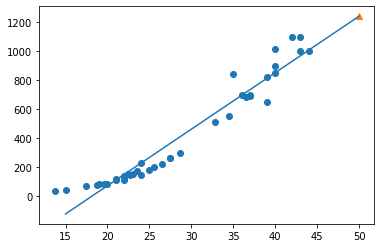

In [14]:
# 훈련 세트의 산점도
plt.scatter(train_input, train_target)
# [x1, x2], [y1, y2] -> [15, 15*39-709], [50,50*39*-709]
plt.plot([15, 50], [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_])
# 50cm 농어 데이터
plt.scatter(50, 1241.8, marker='^')
plt.show()

## 모델 평가하기
### 회귀 알고리즘 평가 : 결정계수 $R^2$

$$
R^2 = 1 - \frac{\sum(타겟 - 예측)^2}{\sum(타겟 - 평균)^2}
$$

In [13]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.939846333997604
0.8247503123313558


훈련세트의 평가 점수와 테스트 세트의 평가 점수 차이가 꽤 나는 것을 확인할 수 있다. 과대적합일까 과소적합일까?

### 과대적합
: 모델의 훈련 세트 성능이 테스트 세트 성능보다 훨씬 높은것

### 과소적합
: 훈련세트와 테스트세트 성능이 둘 다 낮거나 테스트 세트 성능이 더 높은 것

---

## 다항회귀
직선말고 곡선을 그리자.. -> 2차 방정식..$y= ax^2 +bx +c$

$무게 = a * 길이^2 + b*길이 + c$

### 넘파이 이용하여 길이제곱하기
농어의 길이를 제곱해서 컬럼 추가하기

`np.column_stack()` : 매개변수로 두개의 리스트를 받음. 리스트를 일렬로 세운 후 나란히 연결해서 새로운 리스트를 반환한다.

In [ ]:
train_input[:5]

array([[19.6],
       [22. ],
       [18.7],
       [17.4],
       [36. ]])

In [ ]:
 
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [ ]:
train_poly[:5]

array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ]])

In [ ]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

# x^2과 x를 넣어준다 (길이의 제곱, 길이)
print(lr.predict([[50**2, 50]]))

print(lr.coef_, lr.intercept_)  # [a b] c

[1573.98423528]
[  1.01433211 -21.55792498] 116.05021078278259


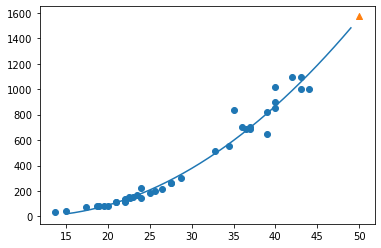

In [ ]:
x = np.arange(15, 50)
plt.scatter(train_input, train_target)
# 15에서 49까지 2차 방정식 그래프
plt.plot(x, 1.01*x**2 - 21.6*x + 116.05)
# 50cm 농어 데이터
plt.scatter([50], [1574], marker='^')
plt.show()

In [ ]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325121


---

# 정리
## 선형회귀
: 훈련세트에 맞는 직선 방정식 찾아주는 알고리즘.

`LinearRegression` 클래스를 사용하여 모델 객체를 생성하고 `fit()`, `predict()`, `score()`한다

직선 방정식을 찾는다는 것은 데이터를 가장 잘 표현하는 **직선의 기울기**와 **절편**을 구한다는 의미.<br>
기울기와 절편은 선형회귀 모델의 **coef_** 과 **intercept_** 속성에 저장되어 있다.

그러나 모델이 너무 단순할 경우 음수값을 측정할 수도 있다. 이를 해결하기 위해서 다항 회귀를 사용한다.